# ETF 动量 + R² 策略参数扫描回测

**策略逻辑：**
- 每隔 `rebal_period` 个交易日做一次调仓
- 调仓时，对每只 ETF 取过去 `n` 天的 log(收盘价)，做线性回归 log(P) = a + b·t
- 用 **斜率 b** 衡量动量强度，用 **R²** 衡量趋势质量
- 仅保留 R² ≥ 阈值的标的，从中选斜率最大的 top_k 只等权持有
- 若无标的通过筛选，该期空仓（收益为 0）

**扫描维度：** n (回看天数) × R² 阈值 × 调仓周期

In [19]:
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
import warnings
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

DB_DIR = Path('db')

## 1. 加载数据

In [20]:
closes = {}
opens = {}
for fp in sorted(DB_DIR.glob('*.csv')):
    df = pd.read_csv(fp, index_col=0, parse_dates=True)
    if not df.empty and 'Close' in df.columns and len(df) >= 30:
        closes[fp.stem] = df['Close']
        if 'Open' in df.columns:
            opens[fp.stem] = df['Open']

# ffill 填充交易日间隙（ETF 上市前仍为 NaN，不会被错误填充）
panel = pd.DataFrame(closes).sort_index().ffill()
panel_open = pd.DataFrame(opens).sort_index().ffill()
print(f'加载 {panel.shape[1]} 只 ETF，{panel.shape[0]} 个交易日')
print(f'日期范围: {panel.index[0].strftime("%Y-%m-%d")} ~ {panel.index[-1].strftime("%Y-%m-%d")}')

加载 177 只 ETF，2963 个交易日
日期范围: 2014-01-02 ~ 2026-03-13


## 2. 回测引擎

利用滚动窗口向量化计算线性回归的斜率和 R²，避免逐只逐日循环。

In [21]:
from momentum_backtest_tool import (
    rolling_linreg,
    precompute_linreg,
    backtest_momentum,
    backtest_momentum_record_trades,
    apply_tp_sl_to_periods,
    period_returns_to_nav,
    SLIPPAGE,
    COMMISSION,
)
# 预计算中间量（panel / panel_open 来自上一 cell 加载）
log_close = np.log(panel.replace(0, np.nan))
daily_ret = panel.pct_change()
linreg_cache = {}
# precompute_linreg(log_close, N_LIST, cache=linreg_cache) 在下方「参数网格」定义 N_LIST 后、Phase 1 中调用



## 3. 定义参数网格

In [22]:
N_LIST = [3, 5, 7, 20, 30]           # 动量回看天数
R2_LIST = [0.3, 0.5, 0.6, 0.7, 0.8]               # R² 阈值
REBAL_LIST = [10, 15, 20, 30, 60]          # 调仓周期
TOP_K_LIST = [1, 2, 3]                             # 每次持有 ETF 数量
# 回测时不设 TP/SL，只跑 (n, r2, rebal, top_k)；TP/SL 由每笔交易 path 后统计得出
TP_LIST = [0.2, 0.3, 0.5, None]                    # 后处理网格：单笔止盈 (None=不限)
SL_DD_LIST = [0.1, 0.2, 0.3, None]                 # 后处理网格：最大回撤止损 (None=不限)

param_grid_core = list(product(N_LIST, R2_LIST, REBAL_LIST, TOP_K_LIST))
param_grid_tp_sl = list(product(TP_LIST, SL_DD_LIST))
print(f'核心参数组合数: {len(param_grid_core)}  (回测只跑这组，无 TP/SL)')
print(f'TP/SL 网格: {len(TP_LIST)}×{len(SL_DD_LIST)} = {len(param_grid_tp_sl)}，由交易 path 后统计得出')

核心参数组合数: 375  (回测只跑这组，无 TP/SL)
TP/SL 网格: 4×4 = 16，由交易 path 后统计得出


## 4. 批量回测（三阶段）
1. **Phase 1（4a）**：不设止盈止损，只跑核心参数 (n, R², rebal, top_k)，记录每笔 path，再在网格上统计得出**最优止盈、最优止损**。
2. **Phase 2（4b）**：用 Phase 1 得出的最优 TP/SL，做一次**真实回测**（引擎内带 TP/SL），与「不设」对比，**列出并比较四类结果**（不设/不设、仅止盈、仅止损、止盈+止损），选出是设还是不设更好（止盈、止损分开看），得到**选用**的 `final_tp`、`final_sl`。
3. **Phase 3（4c）**：基于选用的止盈、止损，对**全部核心参数**再跑一次回测，得到 `results` 与 `nav_cache`，供后续结果总览、维度图、Top5 等使用。

In [23]:
import time as _time
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE
import os as _os

# 预计算所有 n 值的线性回归（最耗时步骤，每个 n 只算一次）
print('预计算 rolling linreg ...')
precompute_linreg(log_close, N_LIST, cache=linreg_cache)

_NUM_WORKERS = max(1, _os.cpu_count() - 1)

def _bt_one(params):
    """核心参数 (n,r2,rebal,top_k) 一次回测（无 TP/SL），记录每笔 path；再对 TP/SL 网格模拟得到多行结果。"""
    n, r2_thresh, rebal, top_k = params
    slope, r2 = linreg_cache[n]
    nav_base, periods = backtest_momentum_record_trades(slope, r2, daily_ret, panel, panel_open, n=n, r2_threshold=r2_thresh,
                                                        rebal_period=rebal, top_k=top_k)
    rows_out = []
    for tp, sl_dd in param_grid_tp_sl:
        period_rets = apply_tp_sl_to_periods(periods, tp, sl_dd, top_k)
        nav = period_returns_to_nav(nav_base.index, rebal, period_rets)
        tp_s = 'inf' if tp is None else str(tp)
        sl_s = 'inf' if sl_dd is None else str(sl_dd)
        label = f'n={n}_R2={r2_thresh}_rebal={rebal}_topk={top_k}_tp={tp_s}_sl={sl_s}'

        years = sorted(nav.index.year.unique())
        annual_rets = {}
        annual_max_dd = {}
        for yr in years:
            yr_nav = nav[nav.index.year == yr]
            if len(yr_nav) < 10:
                continue
            annual_rets[yr] = yr_nav.iloc[-1] / yr_nav.iloc[0] - 1
            annual_max_dd[yr] = ((yr_nav / yr_nav.cummax()) - 1).min()

        full_years = [y for y in annual_rets if y != years[0] and y != years[-1]]
        avg_ret = np.mean([annual_rets[y] for y in full_years]) if full_years else np.nan
        total_ret = nav.iloc[-1] / nav.iloc[0] - 1
        n_years = (nav.index[-1] - nav.index[0]).days / 365.25
        annualized = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
        max_dd = ((nav / nav.cummax()) - 1).min()
        dr = nav.pct_change().dropna()
        sharpe = (dr.mean() / dr.std() * np.sqrt(252)) if dr.std() > 0 else np.nan

        out = {'n': n, 'R2_threshold': r2_thresh, 'rebal_period': rebal, 'top_k': top_k,
               'take_profit': tp, 'max_dd_stop': sl_dd}
        for yr in years:
            if yr in annual_rets:
                out[yr] = annual_rets[yr]
            if yr in annual_max_dd:
                out[f'max_dd_{yr}'] = annual_max_dd[yr]
        out['avg_full_year_12y'] = avg_ret
        out['annualized_12y'] = annualized
        out['total_ret_12y'] = total_ret
        out['sharpe_12y'] = sharpe
        out['max_drawdown_12y'] = max_dd

        last_3_years = sorted(years)[-3:] if len(years) >= 3 else []
        if last_3_years:
            nav_3y = nav[nav.index.year.isin(last_3_years)]
            if len(nav_3y) >= 10:
                total_ret_3y = nav_3y.iloc[-1] / nav_3y.iloc[0] - 1
                n_years_3 = (nav_3y.index[-1] - nav_3y.index[0]).days / 365.25
                annualized_3y = (1 + total_ret_3y) ** (1 / n_years_3) - 1 if n_years_3 > 0 else np.nan
                max_drawdown_3y = ((nav_3y / nav_3y.cummax()) - 1).min()
                dr_3y = nav_3y.pct_change().dropna()
                sharpe_3y = (dr_3y.mean() / dr_3y.std() * np.sqrt(252)) if dr_3y.std() > 0 else np.nan
                for yr in last_3_years:
                    out[f'y{yr}_3y'] = annual_rets.get(yr, np.nan)
                out['annualized_3y'] = annualized_3y
                out['total_ret_3y'] = total_ret_3y
                out['sharpe_3y'] = sharpe_3y
                out['max_drawdown_3y'] = max_drawdown_3y
            else:
                for yr in last_3_years:
                    out[f'y{yr}_3y'] = np.nan
                out['annualized_3y'] = out['total_ret_3y'] = out['sharpe_3y'] = out['max_drawdown_3y'] = np.nan
        else:
            out['annualized_3y'] = out['total_ret_3y'] = out['sharpe_3y'] = out['max_drawdown_3y'] = np.nan

        rows_out.append((label, nav, out))
    return rows_out

# ─── Phase 1：不设止盈止损，回测后由 path 统计得出最优 TP/SL ───
print(f'Phase 1: 使用 {_NUM_WORKERS} 个进程并行回测 {len(param_grid_core)} 组核心参数（无 TP/SL），再对 {len(param_grid_tp_sl)} 组 TP/SL 后统计...')
t0 = _time.time()
_ctx = _mp.get_context('fork')
with _PPE(max_workers=_NUM_WORKERS, mp_context=_ctx) as executor:
    _all_batches = list(executor.map(_bt_one, param_grid_core, chunksize=20))

results_phase1 = []
for row_list in _all_batches:
    for _label, _nav, row in row_list:
        results_phase1.append(row)
elapsed = _time.time() - t0
print(f'Phase 1 完成，共 {len(results_phase1)} 组参数（path 统计），耗时 {elapsed:.1f}s')

预计算 rolling linreg ...
  预计算 rolling_linreg(n=3) 完成
  预计算 rolling_linreg(n=5) 完成
  预计算 rolling_linreg(n=7) 完成
  预计算 rolling_linreg(n=20) 完成
  预计算 rolling_linreg(n=30) 完成
Phase 1: 使用 7 个进程并行回测 375 组核心参数（无 TP/SL），再对 16 组 TP/SL 后统计...
Phase 1 完成，共 6000 组参数（path 统计），耗时 176.1s


## 4b. 止盈/止损 设与不设 对比
用 Phase 1 得出的**最优止盈、最优止损**，再跑一次**真实回测**（引擎内带 TP/SL），与「不设」对比，选出是设还是不设更好（止盈、止损分开看）。

In [24]:
df_phase1 = pd.DataFrame(results_phase1)
best_row = df_phase1.nlargest(1, 'annualized_12y').iloc[0]
best_tp = best_row['take_profit']   # path 统计得出的最优止盈（可能为 None）
best_sl = best_row['max_dd_stop']   # path 统计得出的最优止损（可能为 None）
best_n = int(best_row['n'])
best_r2 = float(best_row['R2_threshold'])
best_rebal = int(best_row['rebal_period'])
best_topk = int(best_row['top_k'])

# Scenario A：不设止盈、不设止损（Phase 1 中 path 无 TP/SL 的那条）
mask_a = (df_phase1['n'] == best_n) & (df_phase1['R2_threshold'] == best_r2) \
         & (df_phase1['rebal_period'] == best_rebal) & (df_phase1['top_k'] == best_topk) \
         & (df_phase1['take_profit'].isna()) & (df_phase1['max_dd_stop'].isna())
row_a = df_phase1.loc[mask_a].iloc[0]

def _run_one_bt(tp, sl):
    slope, r2 = linreg_cache[best_n]
    nav = backtest_momentum(slope, r2, daily_ret, panel, panel_open, n=best_n, r2_threshold=best_r2,
                            rebal_period=best_rebal, top_k=best_topk,
                            take_profit=tp, max_dd_stop=sl)
    total_ret = nav.iloc[-1] / nav.iloc[0] - 1
    n_years = (nav.index[-1] - nav.index[0]).days / 365.25
    ann = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    md = ((nav / nav.cummax()) - 1).min()
    dr = nav.pct_change().dropna()
    sh = (dr.mean() / dr.std() * np.sqrt(252)) if dr.std() > 0 else np.nan
    return ann, total_ret, sh, md

# B：仅设止盈  C：仅设止损  D：止盈+止损
ann_b, ret_b, sh_b, md_b = _run_one_bt(best_tp, None)
ann_c, ret_c, sh_c, md_c = _run_one_bt(None, best_sl)
ann_d, ret_d, sh_d, md_d = _run_one_bt(best_tp, best_sl)

tp_str = lambda x: f'{x:.0%}' if x is not None and not pd.isna(x) else '不设'
compare = pd.DataFrame([
    {'场景': 'A 不设/不设', '止盈': '不设', '止损': '不设',
     '12年年化': row_a['annualized_12y'], '总收益': row_a['total_ret_12y'],
     'Sharpe': row_a['sharpe_12y'], '最大回撤': row_a['max_drawdown_12y']},
    {'场景': 'B 仅止盈', '止盈': tp_str(best_tp), '止损': '不设',
     '12年年化': ann_b, '总收益': ret_b, 'Sharpe': sh_b, '最大回撤': md_b},
    {'场景': 'C 仅止损', '止盈': '不设', '止损': tp_str(best_sl),
     '12年年化': ann_c, '总收益': ret_c, 'Sharpe': sh_c, '最大回撤': md_c},
    {'场景': 'D 止盈+止损', '止盈': tp_str(best_tp), '止损': tp_str(best_sl),
     '12年年化': ann_d, '总收益': ret_d, 'Sharpe': sh_d, '最大回撤': md_d},
])
compare['12年年化'] = compare['12年年化'].astype(float)
best_idx = compare['12年年化'].idxmax()
final_row = compare.loc[best_idx]
final_tp = best_tp if final_row['止盈'] != '不设' else None
final_sl = best_sl if final_row['止损'] != '不设' else None

print('Phase 1 得出的最优止盈 =', tp_str(best_tp), '，最优止损 =', tp_str(best_sl))
print('四场景对比（按 12 年年化）：')
display(compare.style.format({'12年年化': '{:.2%}', '总收益': '{:.2%}', 'Sharpe': '{:.2f}', '最大回撤': '{:.2%}'}))
print(f'选用：止盈 = {tp_str(final_tp)}，止损 = {tp_str(final_sl)}（对应场景 {final_row["场景"]}）')

Phase 1 得出的最优止盈 = 不设 ，最优止损 = 10%
四场景对比（按 12 年年化）：


,场景,止盈,止损,12年年化,总收益,Sharpe,最大回撤
0,A 不设/不设,不设,不设,24.24%,1298.12%,2.90,-61.81%
1,B 仅止盈,不设,不设,26.81%,1693.59%,0.90,-69.82%
2,C 仅止损,不设,10%,32.70%,3013.06%,1.13,-35.97%
3,D 止盈+止损,不设,10%,32.70%,3013.06%,1.13,-35.97%


选用：止盈 = 不设，止损 = 10%（对应场景 C 仅止损）


## 4c. 按选用止盈/止损做全量参数回测
基于 4b 选定的止盈、止损（或「不设」），对**全部核心参数**再跑一次回测，得到 `results` 与 `nav_cache`，供后续结果总览、维度图、Top5 等使用。

In [25]:
def _bt_one_with_tp_sl(params):
    """固定止盈/止损下，单组核心参数回测。"""
    n, r2_thresh, rebal, top_k = params
    slope, r2 = linreg_cache[n]
    nav = backtest_momentum(slope, r2, daily_ret, panel, panel_open, n=n, r2_threshold=r2_thresh,
                            rebal_period=rebal, top_k=top_k,
                            take_profit=final_tp, max_dd_stop=final_sl)
    tp_s = 'inf' if final_tp is None else str(final_tp)
    sl_s = 'inf' if final_sl is None else str(final_sl)
    label = f'n={n}_R2={r2_thresh}_rebal={rebal}_topk={top_k}_tp={tp_s}_sl={sl_s}'

    years = sorted(nav.index.year.unique())
    annual_rets = {}
    annual_max_dd = {}
    for yr in years:
        yr_nav = nav[nav.index.year == yr]
        if len(yr_nav) < 10:
            continue
        annual_rets[yr] = yr_nav.iloc[-1] / yr_nav.iloc[0] - 1
        annual_max_dd[yr] = ((yr_nav / yr_nav.cummax()) - 1).min()
    full_years = [y for y in annual_rets if y != years[0] and y != years[-1]]
    avg_ret = np.mean([annual_rets[y] for y in full_years]) if full_years else np.nan
    total_ret = nav.iloc[-1] / nav.iloc[0] - 1
    n_years = (nav.index[-1] - nav.index[0]).days / 365.25
    annualized = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    max_dd = ((nav / nav.cummax()) - 1).min()
    dr = nav.pct_change().dropna()
    sharpe = (dr.mean() / dr.std() * np.sqrt(252)) if dr.std() > 0 else np.nan

    out = {'n': n, 'R2_threshold': r2_thresh, 'rebal_period': rebal, 'top_k': top_k,
           'take_profit': final_tp, 'max_dd_stop': final_sl}
    for yr in years:
        if yr in annual_rets:
            out[yr] = annual_rets[yr]
        if yr in annual_max_dd:
            out[f'max_dd_{yr}'] = annual_max_dd[yr]
    out['avg_full_year_12y'] = avg_ret
    out['annualized_12y'] = annualized
    out['total_ret_12y'] = total_ret
    out['sharpe_12y'] = sharpe
    out['max_drawdown_12y'] = max_dd

    last_3_years = sorted(years)[-3:] if len(years) >= 3 else []
    if last_3_years:
        nav_3y = nav[nav.index.year.isin(last_3_years)]
        if len(nav_3y) >= 10:
            total_ret_3y = nav_3y.iloc[-1] / nav_3y.iloc[0] - 1
            n_years_3 = (nav_3y.index[-1] - nav_3y.index[0]).days / 365.25
            annualized_3y = (1 + total_ret_3y) ** (1 / n_years_3) - 1 if n_years_3 > 0 else np.nan
            max_drawdown_3y = ((nav_3y / nav_3y.cummax()) - 1).min()
            dr_3y = nav_3y.pct_change().dropna()
            sharpe_3y = (dr_3y.mean() / dr_3y.std() * np.sqrt(252)) if dr_3y.std() > 0 else np.nan
            for yr in last_3_years:
                out[f'y{yr}_3y'] = annual_rets.get(yr, np.nan)
            out['annualized_3y'] = annualized_3y
            out['total_ret_3y'] = total_ret_3y
            out['sharpe_3y'] = sharpe_3y
            out['max_drawdown_3y'] = max_drawdown_3y
        else:
            for yr in last_3_years:
                out[f'y{yr}_3y'] = np.nan
            out['annualized_3y'] = out['total_ret_3y'] = out['sharpe_3y'] = out['max_drawdown_3y'] = np.nan
    else:
        out['annualized_3y'] = out['total_ret_3y'] = out['sharpe_3y'] = out['max_drawdown_3y'] = np.nan

    return label, nav, out

print(f'Phase 3: 使用选用止盈/止损对 {len(param_grid_core)} 组核心参数回测...')
t0 = _time.time()
with _PPE(max_workers=_NUM_WORKERS, mp_context=_ctx) as executor:
    _all_final = list(executor.map(_bt_one_with_tp_sl, param_grid_core, chunksize=20))

results = []
nav_cache = {}
for label, nav, row in _all_final:
    nav_cache[label] = nav
    results.append(row)
print(f'完成，共 {len(results)} 组参数，耗时 {_time.time() - t0:.1f}s。后续结果总览与对比均基于此。')

Phase 3: 使用选用止盈/止损对 375 组核心参数回测...
完成，共 375 组参数，耗时 121.7s。后续结果总览与对比均基于此。


## 5. 结果总览

In [26]:
# 优先使用本次第4步的 results，保证表格与净值图来自同一次回测（避免 3 年 Top5 数字与曲线不一致）
try:
    _use_memory = (results is not None and len(results) > 0 and isinstance(results[0], dict)
                   and 'annualized_12y' in results[0])
except NameError:
    _use_memory = False

if _use_memory:
    result_df = pd.DataFrame(results)
    result_df.to_csv('backtest_result.csv', index=False, encoding='utf-8-sig')
    print(f'已使用本次第4步结果（共 {len(result_df)} 条），表格与净值图一致')
elif Path('backtest_result.csv').exists():
    result_df = pd.read_csv('backtest_result.csv', encoding='utf-8-sig')
    year_cols_raw = [c for c in result_df.columns if isinstance(c, str) and c.isdigit()]
    if year_cols_raw:
        for c in year_cols_raw:
            result_df = result_df.rename(columns={c: int(c)})
    print(f'已从 backtest_result.csv 读取（共 {len(result_df)} 条）；未运行第4步时净值图可能与表格不同源，3年曲线仅供参考')
else:
    result_df = pd.DataFrame()
    print('未找到 backtest_result.csv 且无 results，请先运行第4步')

year_cols = [c for c in result_df.columns if isinstance(c, (int, np.integer))]
fmt_cols = year_cols + ['avg_full_year_12y', 'annualized_12y', 'total_ret_12y', 'sharpe_12y', 'max_drawdown_12y',
                        'annualized_3y', 'total_ret_3y', 'sharpe_3y', 'max_drawdown_3y']
fmt_cols = [c for c in fmt_cols if c in result_df.columns]

display_df = result_df.copy()
display_df['take_profit'] = display_df['take_profit'].map(lambda x: f'{x:.0%}' if pd.notna(x) else '不限')
display_df['max_dd_stop'] = display_df['max_dd_stop'].map(lambda x: f'{x:.0%}' if pd.notna(x) else '不限')
for c in fmt_cols:
    if c in display_df.columns:
        if 'sharpe' in str(c):
            display_df[c] = display_df[c].map(lambda x: f'{x:.2f}' if pd.notna(x) else '-')
        else:
            display_df[c] = display_df[c].map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')

display_df = display_df.sort_values('annualized_12y', ascending=False, key=lambda s: result_df['annualized_12y'])

# 关键列排在前面，避免被截断：参数 + 平均年化/年化/总收益/Sharpe/回撤 + 逐年 + 3年汇总
key_cols = ['n', 'R2_threshold', 'rebal_period', 'top_k', 'take_profit', 'max_dd_stop',
            'avg_full_year_12y', 'annualized_12y', 'total_ret_12y', 'sharpe_12y', 'max_drawdown_12y']
rest = [c for c in display_df.columns if c not in key_cols]
display_df = display_df[key_cols + rest]

print('所有参数组合回测结果（按 12 年年化收益排序，前 30 条）：关键列（含平均年化、年化、总收益）已前置。')
display(display_df.head(30))

已使用本次第4步结果（共 375 条），表格与净值图一致
所有参数组合回测结果（按 12 年年化收益排序，前 30 条）：关键列（含平均年化、年化、总收益）已前置。


,n,R2_threshold,rebal_period,top_k,take_profit,max_dd_stop,avg_full_year_12y,annualized_12y,total_ret_12y,sharpe_12y,...,max_dd_2025,2026,max_dd_2026,y2024_3y,y2025_3y,y2026_3y,annualized_3y,total_ret_3y,sharpe_3y,max_drawdown_3y
84,5,0.3,30,1,不限,10%,32.36%,32.70%,3013.06%,1.13,...,-0.163618,-0.38%,-0.171044,-0.149462,0.224187,-0.003814,2.46%,5.47%,0.24,-32.10%
99,5,0.5,30,1,不限,10%,30.47%,32.16%,2864.52%,1.12,...,-0.163618,-0.38%,-0.171044,-0.149462,0.224187,-0.003814,2.46%,5.47%,0.24,-32.10%
129,5,0.7,30,1,不限,10%,26.31%,29.46%,2205.91%,1.05,...,-0.161826,-0.36%,-0.171044,-0.038637,0.226312,-0.003626,8.45%,19.47%,0.43,-23.25%
114,5,0.6,30,1,不限,10%,28.47%,29.39%,2191.31%,1.07,...,-0.163618,-0.38%,-0.171044,-0.155901,0.224187,-0.003814,2.10%,4.67%,0.23,-32.61%
24,3,0.5,30,1,不限,10%,27.08%,29.01%,2112.74%,1.02,...,-0.277225,15.59%,-0.125255,-0.015964,0.344119,0.155942,22.15%,55.09%,0.83,-27.72%
225,20,0.3,10,1,不限,10%,26.03%,27.48%,1777.19%,0.83,...,-0.358142,2.87%,-0.230550,-0.234385,0.595649,0.028678,9.81%,22.78%,0.44,-43.79%
36,3,0.6,20,1,不限,10%,26.24%,26.84%,1701.12%,0.87,...,-0.319812,-3.43%,-0.125255,0.845595,0.006795,-0.034335,27.03%,68.98%,0.82,-31.98%
126,5,0.7,20,1,不限,10%,22.58%,26.63%,1662.54%,0.91,...,-0.281373,4.37%,-0.125255,0.399844,-0.086759,0.043739,11.08%,25.92%,0.49,-31.50%
69,3,0.8,30,1,不限,10%,24.48%,25.54%,1488.50%,0.94,...,-0.266420,15.64%,-0.125255,0.035710,0.223771,0.156380,21.51%,53.31%,0.82,-26.64%
21,3,0.5,20,1,不限,10%,24.33%,25.22%,1439.53%,0.82,...,-0.351538,-3.43%,-0.125255,0.665223,0.081284,-0.034335,25.22%,63.75%,0.77,-35.15%


## 6. 按维度影响图（12年 vs 3年）

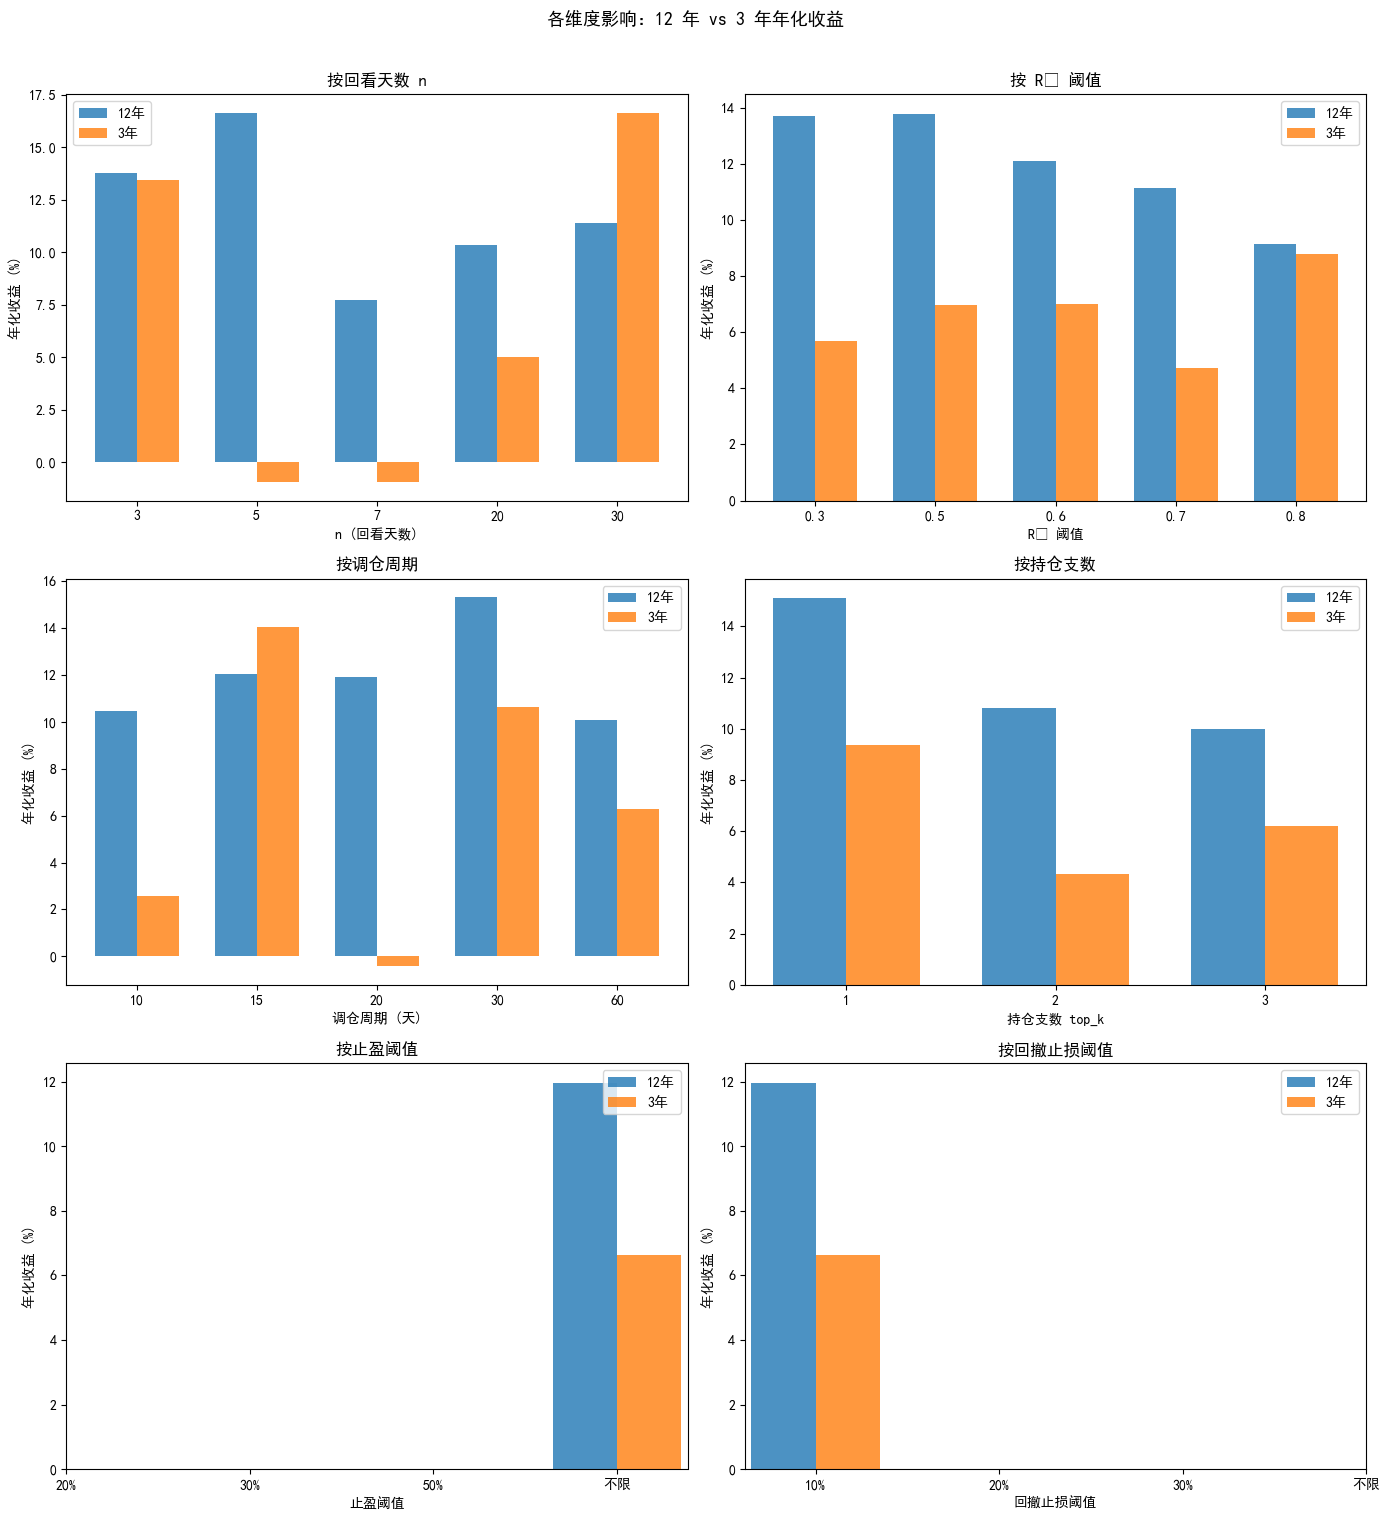

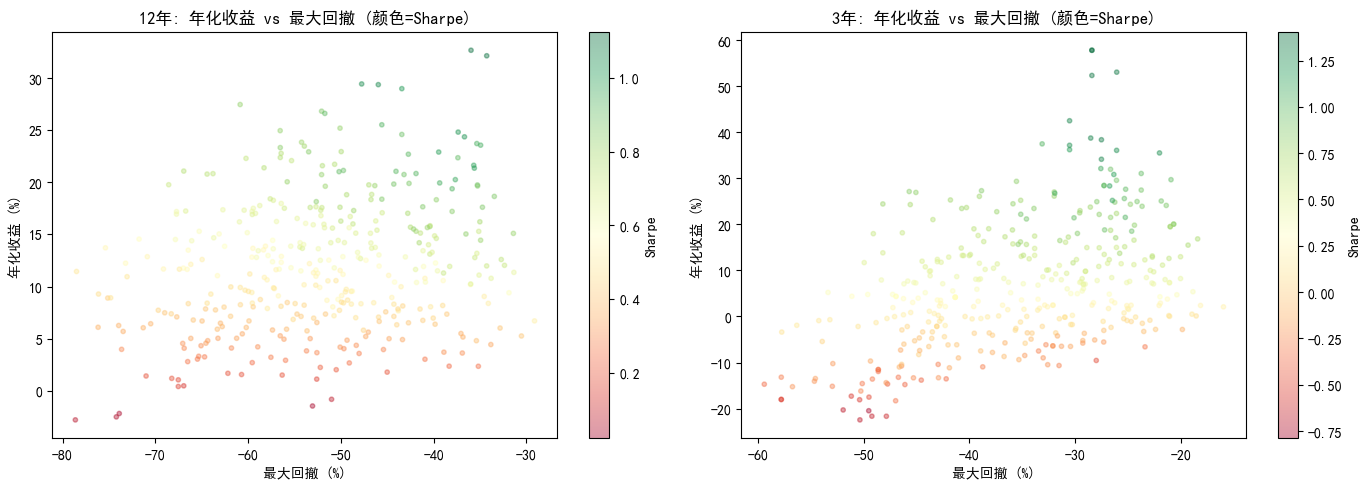

In [27]:


fig, axes = plt.subplots(3, 2, figsize=(14, 15))
w = 0.35

# ── n ──
by_n_12 = result_df.groupby('n')['annualized_12y'].mean() * 100
by_n_3 = result_df.groupby('n')['annualized_3y'].mean() * 100
x = np.arange(len(by_n_12))
axes[0, 0].bar(x - w/2, by_n_12.values, w, label='12年', alpha=0.8)
axes[0, 0].bar(x + w/2, by_n_3.values, w, label='3年', alpha=0.8)
axes[0, 0].set_xticks(x); axes[0, 0].set_xticklabels(by_n_12.index.astype(str))
axes[0, 0].set_xlabel('n (回看天数)'); axes[0, 0].set_ylabel('年化收益 (%)')
axes[0, 0].set_title('按回看天数 n'); axes[0, 0].legend()

# ── R² ──
by_r2_12 = result_df.groupby('R2_threshold')['annualized_12y'].mean() * 100
by_r2_3 = result_df.groupby('R2_threshold')['annualized_3y'].mean() * 100
x2 = np.arange(len(by_r2_12))
axes[0, 1].bar(x2 - w/2, by_r2_12.values, w, label='12年', alpha=0.8)
axes[0, 1].bar(x2 + w/2, by_r2_3.values, w, label='3年', alpha=0.8)
axes[0, 1].set_xticks(x2); axes[0, 1].set_xticklabels([f'{v:.1f}' for v in by_r2_12.index])
axes[0, 1].set_xlabel('R² 阈值'); axes[0, 1].set_ylabel('年化收益 (%)')
axes[0, 1].set_title('按 R² 阈值'); axes[0, 1].legend()

# ── rebal ──
by_r_12 = result_df.groupby('rebal_period')['annualized_12y'].mean() * 100
by_r_3 = result_df.groupby('rebal_period')['annualized_3y'].mean() * 100
x3 = np.arange(len(by_r_12))
axes[1, 0].bar(x3 - w/2, by_r_12.values, w, label='12年', alpha=0.8)
axes[1, 0].bar(x3 + w/2, by_r_3.values, w, label='3年', alpha=0.8)
axes[1, 0].set_xticks(x3); axes[1, 0].set_xticklabels(by_r_12.index.astype(str))
axes[1, 0].set_xlabel('调仓周期 (天)'); axes[1, 0].set_ylabel('年化收益 (%)')
axes[1, 0].set_title('按调仓周期'); axes[1, 0].legend()

# ── top_k ──
by_k_12 = result_df.groupby('top_k')['annualized_12y'].mean() * 100
by_k_3 = result_df.groupby('top_k')['annualized_3y'].mean() * 100
x4 = np.arange(len(by_k_12))
axes[1, 1].bar(x4 - w/2, by_k_12.values, w, label='12年', alpha=0.8)
axes[1, 1].bar(x4 + w/2, by_k_3.values, w, label='3年', alpha=0.8)
axes[1, 1].set_xticks(x4); axes[1, 1].set_xticklabels(by_k_12.index.astype(str))
axes[1, 1].set_xlabel('持仓支数 top_k'); axes[1, 1].set_ylabel('年化收益 (%)')
axes[1, 1].set_title('按持仓支数'); axes[1, 1].legend()

# ── take_profit ──
tp_df = result_df.copy()
tp_df['tp_label'] = tp_df['take_profit'].map(lambda x: f'{x:.0%}' if pd.notna(x) else '不限')
tp_order = ['20%', '30%', '50%', '不限']
tp_grp_12 = tp_df.groupby('tp_label')['annualized_12y'].mean().reindex(tp_order) * 100
tp_grp_3 = tp_df.groupby('tp_label')['annualized_3y'].mean().reindex(tp_order) * 100
x5 = np.arange(len(tp_order))
axes[2, 0].bar(x5 - w/2, tp_grp_12.values, w, label='12年', alpha=0.8)
axes[2, 0].bar(x5 + w/2, tp_grp_3.values, w, label='3年', alpha=0.8)
axes[2, 0].set_xticks(x5); axes[2, 0].set_xticklabels(tp_order)
axes[2, 0].set_xlabel('止盈阈值'); axes[2, 0].set_ylabel('年化收益 (%)')
axes[2, 0].set_title('按止盈阈值'); axes[2, 0].legend()

# ── max_dd_stop ──
sl_df = result_df.copy()
sl_df['sl_label'] = sl_df['max_dd_stop'].map(lambda x: f'{x:.0%}' if pd.notna(x) else '不限')
sl_order = ['10%', '20%', '30%', '不限']
sl_grp_12 = sl_df.groupby('sl_label')['annualized_12y'].mean().reindex(sl_order) * 100
sl_grp_3 = sl_df.groupby('sl_label')['annualized_3y'].mean().reindex(sl_order) * 100
x6 = np.arange(len(sl_order))
axes[2, 1].bar(x6 - w/2, sl_grp_12.values, w, label='12年', alpha=0.8)
axes[2, 1].bar(x6 + w/2, sl_grp_3.values, w, label='3年', alpha=0.8)
axes[2, 1].set_xticks(x6); axes[2, 1].set_xticklabels(sl_order)
axes[2, 1].set_xlabel('回撤止损阈值'); axes[2, 1].set_ylabel('年化收益 (%)')
axes[2, 1].set_title('按回撤止损阈值'); axes[2, 1].legend()

fig.suptitle('各维度影响：12 年 vs 3 年年化收益', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── 额外：收益 vs 回撤散点图 ──
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sc1 = ax1.scatter(result_df['max_drawdown_12y'] * 100, result_df['annualized_12y'] * 100,
                  c=result_df['sharpe_12y'], cmap='RdYlGn', alpha=0.4, s=10)
ax1.set_xlabel('最大回撤 (%)'); ax1.set_ylabel('年化收益 (%)')
ax1.set_title('12年: 年化收益 vs 最大回撤 (颜色=Sharpe)')
plt.colorbar(sc1, ax=ax1, label='Sharpe')

sc2 = ax2.scatter(result_df['max_drawdown_3y'] * 100, result_df['annualized_3y'] * 100,
                  c=result_df['sharpe_3y'], cmap='RdYlGn', alpha=0.4, s=10)
ax2.set_xlabel('最大回撤 (%)'); ax2.set_ylabel('年化收益 (%)')
ax2.set_title('3年: 年化收益 vs 最大回撤 (颜色=Sharpe)')
plt.colorbar(sc2, ax=ax2, label='Sharpe')
plt.tight_layout()
plt.show()

## 7. 四组 Top5 收益走势图
12 年收益 Top5、12 年 Sharpe Top5、3 年收益 Top5、3 年 Sharpe Top5 的净值走势（各一张图）。

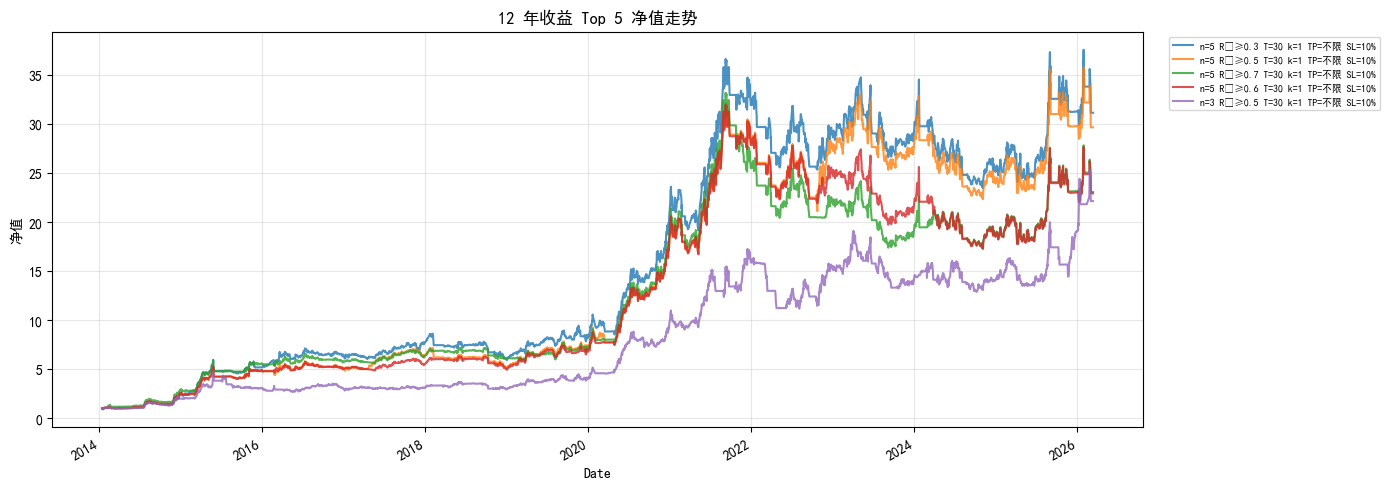

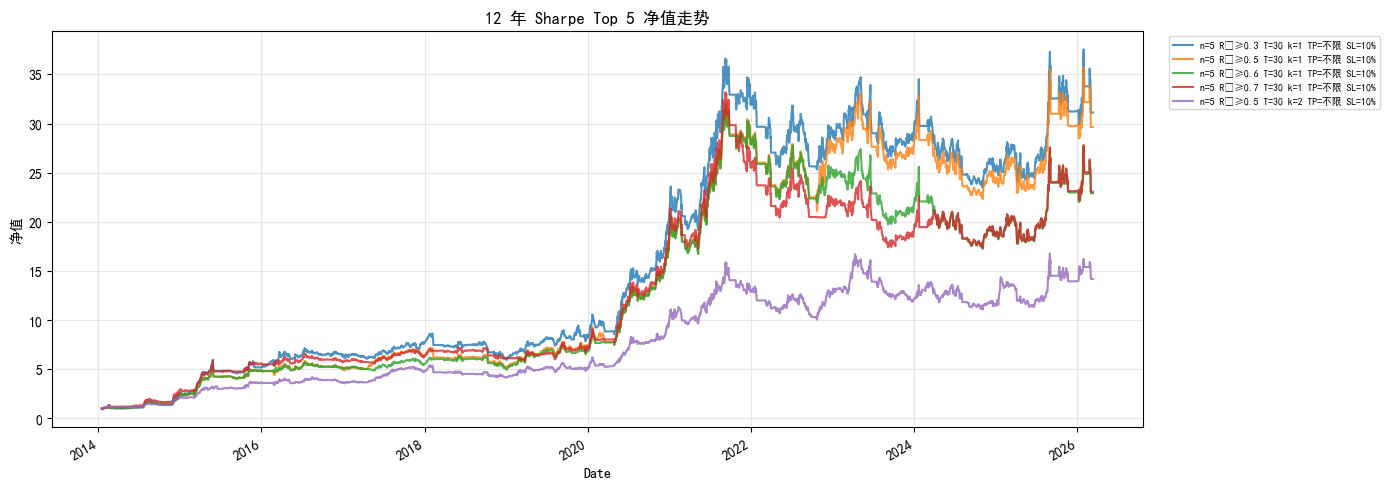

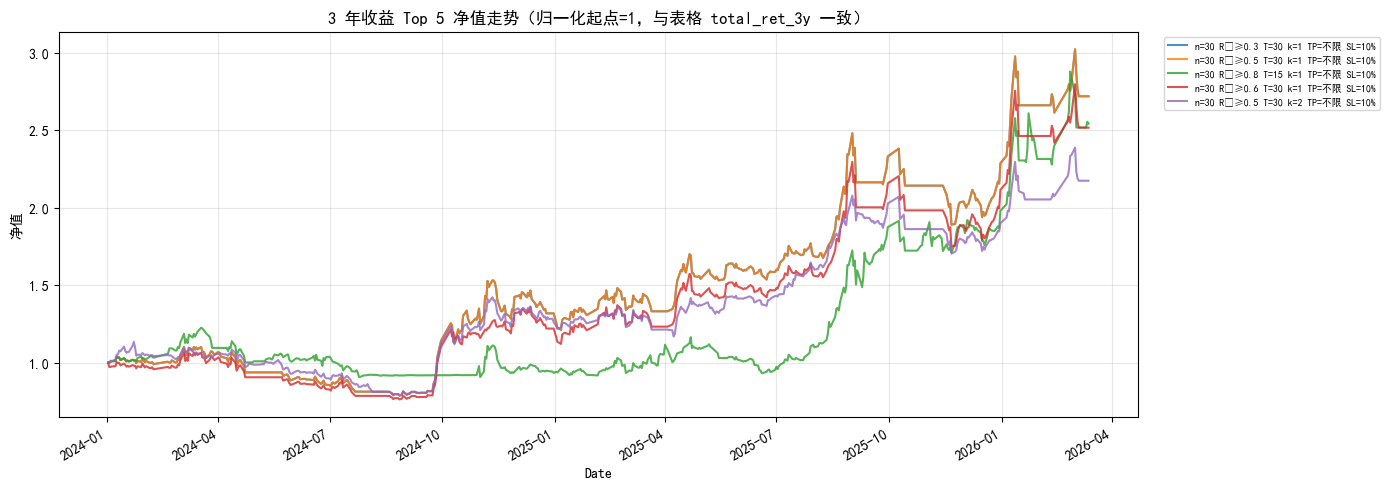

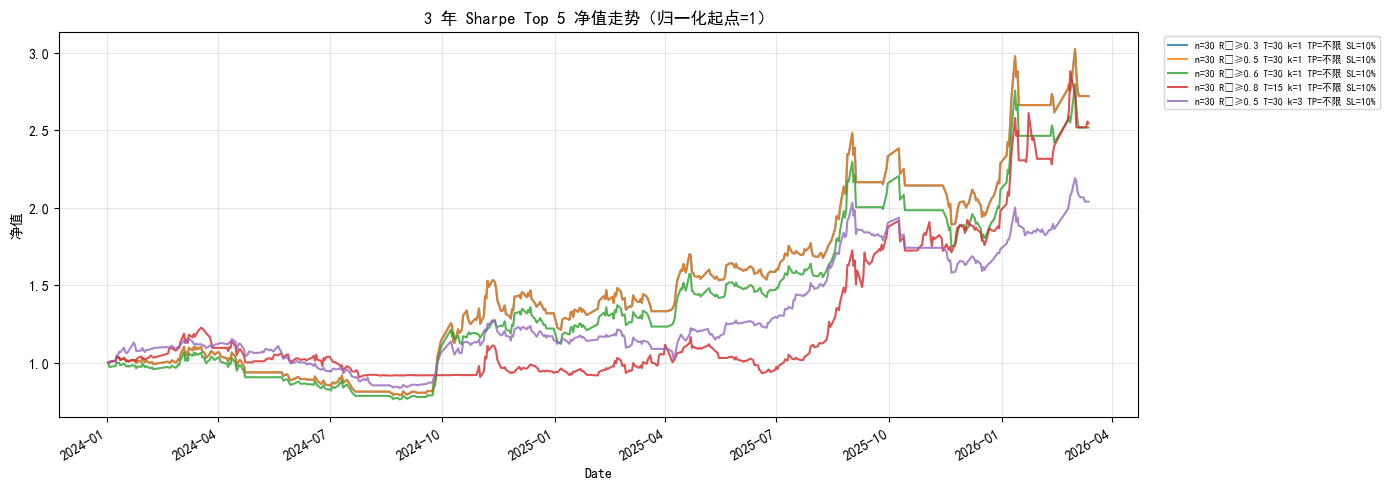

In [28]:
def _nav_key(row):
    n = int(row['n'])
    r2 = round(float(row['R2_threshold']), 4)
    rebal = int(row['rebal_period'])
    top_k = int(row['top_k'])
    tp = row.get('take_profit', None)
    sl = row.get('max_dd_stop', None)
    tp_s = 'inf' if pd.isna(tp) or tp is None else str(tp)
    sl_s = 'inf' if pd.isna(sl) or sl is None else str(sl)
    return f"n={n}_R2={r2}_rebal={rebal}_topk={top_k}_tp={tp_s}_sl={sl_s}"

import re

def _find_nav(cache, row, period='12y'):
    key = _nav_key(row)
    nav = cache.get(key) if key in cache else None
    if nav is None:
        n, r2, rebal, top_k = int(row['n']), round(float(row['R2_threshold']), 4), int(row['rebal_period']), int(row['top_k'])
        tp = row.get('take_profit', None)
        sl = row.get('max_dd_stop', None)
        tp_s = 'inf' if pd.isna(tp) or tp is None else str(tp)
        sl_s = 'inf' if pd.isna(sl) or sl is None else str(sl)
        for k in cache:
            if (f"n={n}_" in k and f"_rebal={rebal}_" in k and f"_topk={top_k}" in k
                    and f"_tp={tp_s}_" in k and f"_sl={sl_s}" in k):
                m = re.search(r'R2=([\d.]+)', k)
                if m and abs(float(m.group(1)) - r2) < 1e-5:
                    nav = cache[k]
                    break
    if nav is None:
        return None
    if period == '3y' and len(nav) >= 10:
        last_3 = sorted(nav.index.year.unique())[-3:]
        nav = nav[nav.index.year.isin(last_3)].copy()
        # 归一化到起点=1，曲线形态与表格 total_ret_3y 一致（终点≈1+total_ret_3y）
        nav = nav / nav.iloc[0]
    return nav

def _make_label(row):
    tp_s = f"{row['take_profit']:.0%}" if pd.notna(row.get('take_profit')) else '不限'
    sl_s = f"{row['max_dd_stop']:.0%}" if pd.notna(row.get('max_dd_stop')) else '不限'
    return f"n={int(row['n'])} R\u00b2\u2265{row['R2_threshold']} T={int(row['rebal_period'])} k={int(row['top_k'])} TP={tp_s} SL={sl_s}"

# 1) 12 年收益 Top 5 走势
top5_ret_12y = result_df.nlargest(5, 'total_ret_12y')
fig, ax = plt.subplots(figsize=(14, 5))
for _, row in top5_ret_12y.iterrows():
    nav = _find_nav(nav_cache, row, '12y')
    if nav is not None:
        nav.plot(ax=ax, label=_make_label(row), alpha=0.8)
ax.set_title('12 年收益 Top 5 净值走势'); ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax.set_ylabel('净值'); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# 2) 12 年 Sharpe Top 5 走势
top5_sharpe_12y = result_df.nlargest(5, 'sharpe_12y')
fig, ax = plt.subplots(figsize=(14, 5))
for _, row in top5_sharpe_12y.iterrows():
    nav = _find_nav(nav_cache, row, '12y')
    if nav is not None:
        nav.plot(ax=ax, label=_make_label(row), alpha=0.8)
ax.set_title('12 年 Sharpe Top 5 净值走势'); ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax.set_ylabel('净值'); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# 3) 3 年收益 Top 5 走势（同一回测的近 3 年段）
top5_ret_3y = result_df.nlargest(5, 'total_ret_3y')
fig, ax = plt.subplots(figsize=(14, 5))
for _, row in top5_ret_3y.iterrows():
    nav = _find_nav(nav_cache, row, '3y')
    if nav is not None:
        nav.plot(ax=ax, label=_make_label(row), alpha=0.8)
ax.set_title('3 年收益 Top 5 净值走势（归一化起点=1，与表格 total_ret_3y 一致）'); ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax.set_ylabel('净值'); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# 4) 3 年 Sharpe Top 5 走势
top5_sharpe_3y = result_df.nlargest(5, 'sharpe_3y')
fig, ax = plt.subplots(figsize=(14, 5))
for _, row in top5_sharpe_3y.iterrows():
    nav = _find_nav(nav_cache, row, '3y')
    if nav is not None:
        nav.plot(ax=ax, label=_make_label(row), alpha=0.8)
ax.set_title('3 年 Sharpe Top 5 净值走势（归一化起点=1）'); ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax.set_ylabel('净值'); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 8. 四组 Top5 年收益表
上述四组 Top5 的逐年收益（12 年组为 2014–2026 年，3 年组为对应近 3 年年份）。

In [29]:
def _fmt_pct(s):
    return s.map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')

def _fmt_tp_sl(df):
    df = df.copy()
    df['take_profit'] = df['take_profit'].map(lambda x: f'{x:.0%}' if pd.notna(x) else '不限')
    df['max_dd_stop'] = df['max_dd_stop'].map(lambda x: f'{x:.0%}' if pd.notna(x) else '不限')
    return df

param_cols = ['n', 'R2_threshold', 'rebal_period', 'top_k', 'take_profit', 'max_dd_stop']
summary_12y = ['annualized_12y', 'total_ret_12y', 'sharpe_12y', 'max_drawdown_12y']
summary_3y = ['annualized_3y', 'total_ret_3y', 'sharpe_3y', 'max_drawdown_3y']

# 1) 12 年收益 Top 5
print('【12 年收益 Top 5】年收益 + 汇总')
tbl = top5_ret_12y[param_cols + year_cols + summary_12y].copy()
tbl = _fmt_tp_sl(tbl)
for c in year_cols + ['annualized_12y', 'total_ret_12y', 'max_drawdown_12y']:
    tbl[c] = _fmt_pct(tbl[c])
tbl['sharpe_12y'] = tbl['sharpe_12y'].map(lambda x: f'{x:.2f}' if pd.notna(x) else '-')
tbl.index = range(1, len(tbl) + 1); tbl.index.name = '排名'
display(tbl)

# 2) 12 年 Sharpe Top 5
print('\n【12 年 Sharpe Top 5】年收益 + 汇总')
tbl2 = top5_sharpe_12y[param_cols + year_cols + summary_12y].copy()
tbl2 = _fmt_tp_sl(tbl2)
for c in year_cols + ['annualized_12y', 'total_ret_12y', 'max_drawdown_12y']:
    tbl2[c] = _fmt_pct(tbl2[c])
tbl2['sharpe_12y'] = tbl2['sharpe_12y'].map(lambda x: f'{x:.2f}' if pd.notna(x) else '-')
tbl2.index = range(1, len(tbl2) + 1); tbl2.index.name = '排名'
display(tbl2)

# 3) 3 年收益 Top 5
y3_cols = [c for c in result_df.columns if str(c).startswith('y') and '_3y' in str(c)]
if y3_cols:
    print('\n【3 年收益 Top 5】年收益 + 汇总')
    tbl3 = top5_ret_3y[param_cols + y3_cols + summary_3y].copy()
    tbl3 = _fmt_tp_sl(tbl3)
    for c in y3_cols + ['annualized_3y', 'total_ret_3y', 'max_drawdown_3y']:
        tbl3[c] = _fmt_pct(tbl3[c])
    tbl3['sharpe_3y'] = tbl3['sharpe_3y'].map(lambda x: f'{x:.2f}' if pd.notna(x) else '-')
    tbl3.columns = [c.replace('_3y', '').replace('y', '') if c.startswith('y') else c for c in tbl3.columns]
    tbl3.index = range(1, len(tbl3) + 1); tbl3.index.name = '排名'
    display(tbl3)

    print('\n【3 年 Sharpe Top 5】年收益 + 汇总')
    tbl4 = top5_sharpe_3y[param_cols + y3_cols + summary_3y].copy()
    tbl4 = _fmt_tp_sl(tbl4)
    for c in y3_cols + ['annualized_3y', 'total_ret_3y', 'max_drawdown_3y']:
        tbl4[c] = _fmt_pct(tbl4[c])
    tbl4['sharpe_3y'] = tbl4['sharpe_3y'].map(lambda x: f'{x:.2f}' if pd.notna(x) else '-')
    tbl4.columns = [c.replace('_3y', '').replace('y', '') if c.startswith('y') else c for c in tbl4.columns]
    tbl4.index = range(1, len(tbl4) + 1); tbl4.index.name = '排名'
    display(tbl4)

【12 年收益 Top 5】年收益 + 汇总


,n,R2_threshold,rebal_period,top_k,take_profit,max_dd_stop,2014,2015,2016,2017,...,2021,2022,2023,2024,2025,2026,annualized_12y,total_ret_12y,sharpe_12y,max_drawdown_12y
排名,,,,,,,,,,,,,,,,,,,,,
1,5,0.3,30,1,不限,10%,144.63%,108.49%,25.35%,18.77%,...,45.20%,-10.16%,-0.57%,-14.95%,22.42%,-0.38%,32.70%,3013.06%,1.13,-35.97%
2,5,0.5,30,1,不限,10%,157.08%,87.78%,6.89%,24.00%,...,45.20%,-2.48%,-0.57%,-14.95%,22.42%,-0.38%,32.16%,2864.52%,1.12,-34.28%
3,5,0.7,30,1,不限,10%,191.51%,89.18%,4.40%,8.22%,...,28.08%,-14.47%,-14.53%,-3.86%,22.63%,-0.36%,29.46%,2205.91%,1.05,-47.76%
4,5,0.6,30,1,不限,10%,157.08%,87.78%,4.40%,8.28%,...,45.20%,-11.13%,-14.53%,-15.59%,22.42%,-0.38%,29.39%,2191.31%,1.07,-45.97%
5,3,0.5,30,1,不限,10%,99.87%,54.90%,-1.15%,3.02%,...,55.09%,-4.49%,-9.04%,-1.60%,34.41%,15.59%,29.01%,2112.74%,1.02,-43.43%



【12 年 Sharpe Top 5】年收益 + 汇总


,n,R2_threshold,rebal_period,top_k,take_profit,max_dd_stop,2014,2015,2016,2017,...,2021,2022,2023,2024,2025,2026,annualized_12y,total_ret_12y,sharpe_12y,max_drawdown_12y
排名,,,,,,,,,,,,,,,,,,,,,
1,5,0.3,30,1,不限,10%,144.63%,108.49%,25.35%,18.77%,...,45.20%,-10.16%,-0.57%,-14.95%,22.42%,-0.38%,32.70%,3013.06%,1.13,-35.97%
2,5,0.5,30,1,不限,10%,157.08%,87.78%,6.89%,24.00%,...,45.20%,-2.48%,-0.57%,-14.95%,22.42%,-0.38%,32.16%,2864.52%,1.12,-34.28%
3,5,0.6,30,1,不限,10%,157.08%,87.78%,4.40%,8.28%,...,45.20%,-11.13%,-14.53%,-15.59%,22.42%,-0.38%,29.39%,2191.31%,1.07,-45.97%
4,5,0.7,30,1,不限,10%,191.51%,89.18%,4.40%,8.22%,...,28.08%,-14.47%,-14.53%,-3.86%,22.63%,-0.36%,29.46%,2205.91%,1.05,-47.76%
5,5,0.5,30,2,不限,10%,114.52%,68.90%,1.33%,29.53%,...,20.94%,-2.38%,-5.98%,-5.85%,20.47%,1.65%,24.38%,1317.68%,1.03,-36.68%



【3 年收益 Top 5】年收益 + 汇总


,n,R2_threshold,rebal_period,top_k,take_profit,max_dd_stop,2024,2025,2026,annualized_3y,total_ret_3y,sharpe_3y,max_drawdown_3y
排名,,,,,,,,,,,,,
1,30,0.3,30,1,不限,10%,31.80%,81.36%,16.44%,57.80%,171.92%,1.41,-28.41%
2,30,0.5,30,1,不限,10%,31.80%,81.36%,16.44%,57.80%,171.92%,1.41,-28.41%
3,30,0.8,15,1,不限,10%,-6.64%,110.47%,25.70%,53.04%,154.26%,1.36,-26.06%
4,30,0.6,30,1,不限,10%,21.98%,81.36%,16.44%,52.32%,151.66%,1.38,-28.41%
5,30,0.5,30,2,不限,10%,26.20%,53.44%,12.27%,42.49%,117.40%,1.31,-30.53%



【3 年 Sharpe Top 5】年收益 + 汇总


,n,R2_threshold,rebal_period,top_k,take_profit,max_dd_stop,2024,2025,2026,annualized_3y,total_ret_3y,sharpe_3y,max_drawdown_3y
排名,,,,,,,,,,,,,
1,30,0.3,30,1,不限,10%,31.80%,81.36%,16.44%,57.80%,171.92%,1.41,-28.41%
2,30,0.5,30,1,不限,10%,31.80%,81.36%,16.44%,57.80%,171.92%,1.41,-28.41%
3,30,0.6,30,1,不限,10%,21.98%,81.36%,16.44%,52.32%,151.66%,1.38,-28.41%
4,30,0.8,15,1,不限,10%,-6.64%,110.47%,25.70%,53.04%,154.26%,1.36,-26.06%
5,30,0.5,30,3,不限,10%,14.52%,52.50%,15.40%,38.37%,103.84%,1.35,-27.51%


## 9. 最优参数调仓明细（自动取 Top1）
**测出的 take_profit / max_dd_stop 最优值**：见本小节运行后**第一段打印**里的「止盈=…」「回撤止损=…」（由全量回测按 12 年年化取 Top1 的那组参数得到，TP/SL 来自对交易 path 的网格统计）。

In [30]:
import json as _json
with open('etf_all.json') as _f:
    _etf_data = _json.load(_f)
etf_name_map = {item['symbol']: item['name'] for item in _etf_data['data']['list']}

_best = result_df.nlargest(1, 'annualized_12y').iloc[0]
BEST_N = int(_best['n'])
BEST_R2 = _best['R2_threshold']
BEST_REBAL = int(_best['rebal_period'])
BEST_TOPK = int(_best['top_k'])
BEST_TP = _best['take_profit'] if pd.notna(_best['take_profit']) else None
BEST_SL = _best['max_dd_stop'] if pd.notna(_best['max_dd_stop']) else None
tp_disp = f'{BEST_TP:.0%}' if BEST_TP is not None else '不限'
sl_disp = f'{BEST_SL:.0%}' if BEST_SL is not None else '不限'

print('【测出的最优 take_profit / max_dd_stop】', f'止盈={tp_disp}, 回撤止损={sl_disp}')
print(f'从全量回测 Top1 提取最优参数: n={BEST_N}, R²≥{BEST_R2}, rebal={BEST_REBAL}, '
      f'top_k={BEST_TOPK}, 止盈={tp_disp}, 回撤止损={sl_disp}')
print(f'  年化收益={_best["annualized_12y"]:.2%}, 总收益={_best["total_ret_12y"]:.2%}, '
      f'Sharpe={_best["sharpe_12y"]:.2f}, 最大回撤={_best["max_drawdown_12y"]:.2%}')

slope, r2 = linreg_cache[BEST_N]
start_idx = BEST_N + 5
dates = daily_ret.index[start_idx:]
rebal_indices = list(range(0, len(dates), BEST_REBAL))

trades = []
cum = 1.0
prev_selected = []
entry_prices = {}
position_alive = {}
period_peak = 1.0
dd_stopped = False

for i, idx_pos in enumerate(rebal_indices):
    date = dates[idx_pos]
    s = slope.loc[date].dropna()
    r = r2.loc[date].dropna()
    common = s.index.intersection(r.index)
    s, r = s[common], r[common]

    candidates = s[r >= BEST_R2].sort_values(ascending=False)
    selected = candidates.head(BEST_TOPK).index.tolist() if len(candidates) >= 1 else []

    exec_idx = idx_pos + 1
    if exec_idx >= len(dates):
        break

    next_signal_idx = rebal_indices[i + 1] if i + 1 < len(rebal_indices) else len(dates) - 1
    next_exec_idx = next_signal_idx + 1

    signal_date = dates[idx_pos]
    exec_date = dates[exec_idx]

    any_dead = any(not position_alive.get(ss, True) for ss in prev_selected)
    changed = sorted(selected) != sorted(prev_selected) or dd_stopped or any_dead
    trade_cost = 0.0
    if changed:
        alive_old = [ss for ss in prev_selected if position_alive.get(ss, True)]
        if alive_old:
            trade_cost += COMMISSION * len(alive_old) / BEST_TOPK
        if selected:
            trade_cost += COMMISSION * len(selected) / BEST_TOPK
        cum *= (1 - trade_cost)

    if selected and changed:
        buy_prices = {}
        for sym in selected:
            op = panel_open.loc[exec_date, sym] if (exec_date in panel_open.index and sym in panel_open.columns) else panel.loc[exec_date, sym]
            buy_prices[sym] = op * (1 + SLIPPAGE)

        sell_prices = {}
        if next_exec_idx < len(dates):
            sell_date = dates[next_exec_idx]
            for sym in selected:
                op = panel_open.loc[sell_date, sym] if (sell_date in panel_open.index and sym in panel_open.columns) else panel.loc[sell_date, sym]
                sell_prices[sym] = op * (1 - SLIPPAGE)
        else:
            sell_date = dates[-1]
            for sym in selected:
                sell_prices[sym] = panel.loc[sell_date, sym]

        per_stock_rets = [(sell_prices[sym] / buy_prices[sym] - 1) for sym in selected]
        period_ret = np.mean(per_stock_rets)
        cum *= (1 + period_ret)

        buy_str = ','.join(f'{buy_prices[s]:.4f}' for s in selected)
        sell_str = ','.join(f'{sell_prices[s]:.4f}' for s in selected)
    else:
        period_ret = 0.0
        sell_date = dates[min(next_signal_idx, len(dates) - 1)]
        buy_str = '-'
        sell_str = '-'

    entry_prices = {sym: buy_prices[sym] for sym in selected} if selected and changed else entry_prices
    position_alive = {sym: True for sym in selected} if selected and changed else position_alive
    period_peak = cum if changed else period_peak
    dd_stopped = False

    prev_selected = selected

    tp_note = ''
    if BEST_TP is not None:
        tp_note = f'TP={BEST_TP:.0%}'
    if BEST_SL is not None:
        tp_note += f'{" " if tp_note else ""}SL={BEST_SL:.0%}'

    trades.append({
        '标的': ','.join(selected) if selected else '空仓',
        '名称': ','.join(etf_name_map.get(s, '-') for s in selected) if selected else '-',
        '信号日(T)': signal_date.strftime('%Y-%m-%d'),
        '执行日(T+1)': exec_date.strftime('%Y-%m-%d'),
        '买入价(open×1.001)': buy_str,
        '卖出日': sell_date.strftime('%Y-%m-%d'),
        '卖出价(open×0.999)': sell_str,
        '收益(卖/买-1)': f'{period_ret:.2%}',
        '手续费': f'{trade_cost:.4%}',
        '总净值': round(cum, 4),
        '风控': tp_note if tp_note else '-',
    })

trade_df = pd.DataFrame(trades)
trade_df.to_csv('trade_detail.csv', index=False, encoding='utf-8-sig')
print(f'共 {len(trade_df)} 次调仓，已导出 trade_detail.csv')
print(f'（注：明细表为调仓级别，止盈/止损的日内平仓已在回测净值中体现）')
display(trade_df)

【测出的最优 take_profit / max_dd_stop】 止盈=不限, 回撤止损=10%
从全量回测 Top1 提取最优参数: n=5, R²≥0.3, rebal=30, top_k=1, 止盈=不限, 回撤止损=10%
  年化收益=32.70%, 总收益=3013.06%, Sharpe=1.13, 最大回撤=-35.97%
共 99 次调仓，已导出 trade_detail.csv
（注：明细表为调仓级别，止盈/止损的日内平仓已在回测净值中体现）


,标的,名称,信号日(T),执行日(T+1),买入价(open×1.001),卖出日,卖出价(open×0.999),收益(卖/买-1),手续费,总净值,风控
0,SZ159915,创业板ETF易方达,2014-01-16,2014-01-17,1.3664,2014-03-07,1.4236,4.19%,0.0060%,1.0418,SL=10%
1,SZ159915,创业板ETF易方达,2014-03-06,2014-03-07,-,2014-04-18,-,0.00%,0.0000%,1.0418,SL=10%
2,SH513500,标普500ETF博时,2014-04-18,2014-04-21,0.5175,2014-06-05,0.5485,5.98%,0.0120%,1.1039,SL=10%
3,SH510900,恒生中国企业ETF易方达,2014-06-04,2014-06-05,0.9059,2014-07-17,0.9441,4.21%,0.0120%,1.1503,SL=10%
4,SH510880,红利ETF华泰柏瑞,2014-07-16,2014-07-17,0.3143,2014-08-28,0.4346,38.26%,0.0120%,1.5902,SL=10%
...,...,...,...,...,...,...,...,...,...,...,...
94,SH515880,通信ETF,2025-08-21,2025-08-22,0.6937,2025-10-13,0.8322,19.96%,0.0120%,19.2783,SL=10%
95,SH560860,工业有色ETF万家,2025-10-10,2025-10-13,1.3794,2025-11-24,1.3287,-3.68%,0.0120%,18.5674,SL=10%
96,SZ159972,5年地债ETF,2025-11-21,2025-11-24,117.2692,2026-01-07,116.9020,-0.31%,0.0120%,18.5070,SL=10%
97,SH513310,中韩半导体ETF,2026-01-06,2026-01-07,3.1071,2026-02-26,4.0949,31.79%,0.0120%,24.3878,SL=10%


## 10. 当前应持仓标的（使用 Top1 最优参数）

In [31]:
latest_date = panel.index[-1]
s_now = slope.loc[latest_date].dropna()
r_now = r2.loc[latest_date].dropna()
common = s_now.index.intersection(r_now.index)
s_now, r_now = s_now[common], r_now[common]

candidates = s_now[r_now >= BEST_R2].sort_values(ascending=False)

tp_disp = f'{BEST_TP:.0%}' if BEST_TP is not None else '不限'
sl_disp = f'{BEST_SL:.0%}' if BEST_SL is not None else '不限'
print(f'策略参数: n={BEST_N}, R²≥{BEST_R2}, rebal={BEST_REBAL}, top_k={BEST_TOPK}, 止盈={tp_disp}, 回撤止损={sl_disp}')
print(f'信号日期: {latest_date.strftime("%Y-%m-%d")}')
print()

if len(candidates) >= 1:
    pick = candidates.head(BEST_TOPK)
    print('当前应持仓标的:')
    for sym, slp in pick.items():
        r2_val = r_now[sym]
        price = panel.loc[latest_date, sym]
        name = etf_name_map.get(sym, '')
        print(f'  {sym} {name}  斜率={slp:.6f}  R²={r2_val:.4f}  最新价={price:.4f}')
else:
    print('当前无标的通过筛选 → 空仓')

print()
print(f'所有通过 R²≥{BEST_R2} 筛选的候选标的 (共 {len(candidates)} 只):')
cand_df = pd.DataFrame({
    '标的': candidates.index,
    '名称': [etf_name_map.get(s, '') for s in candidates.index],
    '斜率': candidates.values,
    'R²': [r_now[s] for s in candidates.index],
    '最新价': [panel.loc[latest_date, s] for s in candidates.index],
}).reset_index(drop=True)
display(cand_df.head(20))

策略参数: n=5, R²≥0.3, rebal=30, top_k=1, 止盈=不限, 回撤止损=10%
信号日期: 2026-03-13

当前应持仓标的:
  SH515220 煤炭ETF  斜率=0.017506  R²=0.6191  最新价=1.3390

所有通过 R²≥0.3 筛选的候选标的 (共 104 只):


,标的,名称,斜率,R²,最新价
0,SH515220,煤炭ETF,0.017506,0.619073,1.339
1,SZ159790,碳中和ETF,0.016564,0.947581,0.865
2,SH516160,新能源ETF,0.015752,0.948016,3.284
3,SH516970,基建ETF广发,0.015746,0.978377,1.345
4,SZ159755,电池ETF,0.015438,0.941893,1.141
5,SZ159840,锂电池ETF工银,0.014663,0.934793,0.912
6,SH515030,新能源车ETF,0.012943,0.897935,1.936
7,SZ159611,电力ETF,0.011933,0.786251,1.192
8,SH562550,绿电ETF,0.011639,0.725708,1.292
9,SZ159761,新材料ETF国泰,0.009905,0.931096,0.814


## 11. 12-1 动量策略回测

> **⚠️ 需要先运行前面 §1~§4 的全部 Cell（加载数据、回测引擎、参数网格、批量回测）**

经典的 **Jegadeesh & Titman (1993)** 12-1 动量因子：

| 参数 | 值 | 学术依据 |
|------|------|----------|
| 回看窗口 | 252 日（12 个月） | 原始论文标准 |
| 跳过近期 | 21 日（1 个月） | 规避短期均值回复效应（short-term reversal） |
| R² 阈值 | ≥ 0.7 | 趋势质量过滤——R² 高意味着上涨趋势稳定线性，非随机波动 |
| 调仓周期 | 21 日（月频） | 与跳过期对齐，月度调仓是动量策略的标准频率 |
| 持仓数 top_k | 3 | ETF 轮动中 3 只提供适度分散，避免单只集中风险 |

上述参数固定不动，仅在**止盈 / 止损**上做网格搜索，观察风控对收益-回撤的影响。

12-1 动量信号计算完成: 回看252日跳过21日, 窗口231日
固定参数: R²≥0.7, 调仓21日, top_k=3
风控网格: 16 组 (4TP × 4SL)
12-1 策略回测完成, 耗时 21.7s

12-1 动量策略 (R²≥0.7, 调仓21日, top_k=3)
全部风控组合 (按 Sharpe 排序):


,take_profit,max_dd_stop,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,avg_full_year,annualized,total_ret,sharpe,max_drawdown
排名,,,,,,,,,,,,,,,,,,,
1,20%,10%,86.73%,5.15%,23.52%,-17.27%,12.01%,31.52%,25.65%,-14.57%,-20.79%,9.80%,-4.33%,-4.47%,5.07%,8.99%,160.87%,0.56,-44.92%
2,不限,10%,76.91%,6.33%,23.52%,-17.27%,12.01%,34.64%,31.78%,-15.33%,-20.79%,9.80%,-3.67%,-4.47%,6.10%,9.33%,170.00%,0.56,-46.54%
3,50%,10%,76.91%,6.33%,23.52%,-17.27%,12.01%,34.64%,29.77%,-15.33%,-20.79%,9.80%,-3.67%,-4.47%,5.90%,9.17%,165.87%,0.55,-46.54%
4,30%,10%,72.44%,12.25%,23.52%,-17.27%,12.01%,32.77%,19.23%,-15.33%,-20.79%,9.80%,-3.67%,-4.47%,5.25%,8.48%,147.56%,0.52,-46.54%
5,20%,20%,24.99%,3.05%,27.85%,-15.85%,13.25%,46.35%,7.86%,-5.26%,-13.72%,13.52%,-6.78%,-2.14%,7.03%,7.09%,114.57%,0.43,-45.33%
6,30%,20%,21.98%,12.25%,27.85%,-15.85%,13.25%,48.28%,-0.27%,-6.37%,-13.72%,13.52%,-6.14%,-2.14%,7.28%,7.07%,114.13%,0.42,-44.67%
7,不限,30%,5.77%,4.20%,27.75%,-15.85%,13.25%,55.87%,7.44%,-5.11%,-13.72%,13.19%,-8.83%,4.98%,7.82%,7.00%,112.54%,0.41,-52.78%
8,50%,30%,8.64%,4.20%,27.75%,-15.85%,13.25%,55.87%,3.62%,-5.11%,-13.72%,13.19%,-8.83%,4.98%,7.44%,6.91%,110.55%,0.41,-52.78%
9,不限,20%,11.30%,4.20%,27.85%,-15.85%,13.25%,50.37%,12.78%,-6.37%,-13.72%,13.52%,-6.14%,-2.14%,7.99%,6.81%,108.23%,0.41,-50.32%


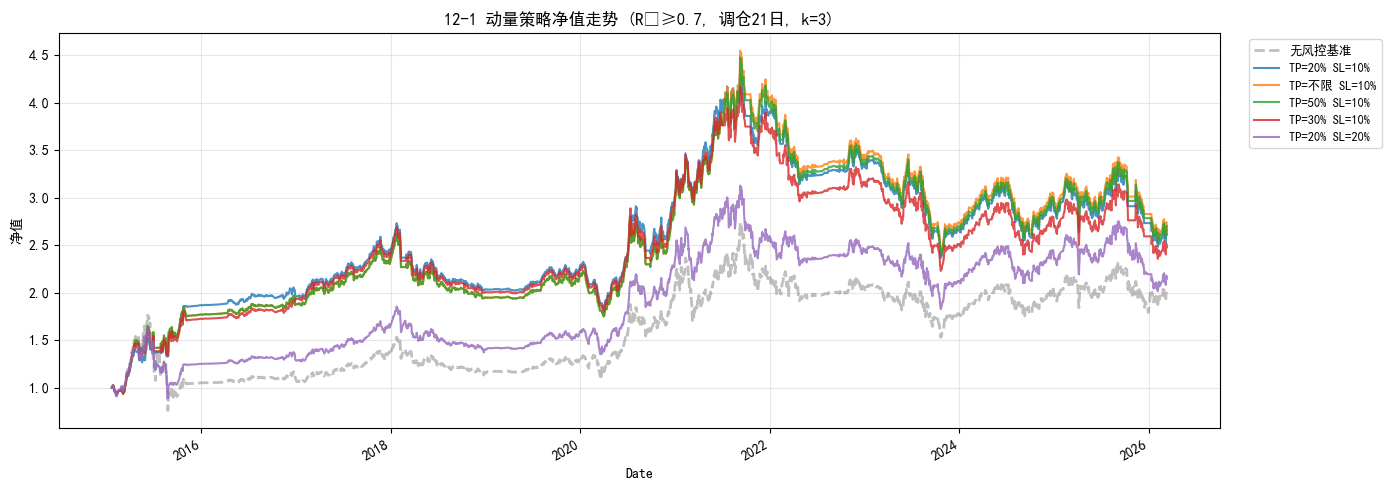


当前 12-1 信号 (2026-03-13):
  SH515880 通信ETF  斜率=0.005340  R²=0.8999  最新价=1.0850
  SZ159583 通信设备ETF  斜率=0.004912  R²=0.9095  最新价=1.3730
  SH560860 工业有色ETF万家  斜率=0.003985  R²=0.9158  最新价=1.8960


In [16]:
# ═══════════════════════════════════════════════════════════════
# 12-1 动量信号：回看12个月(252日)跳过最近1个月(21日)
# ═══════════════════════════════════════════════════════════════
LOOKBACK_12 = 252    # 12个月
SKIP_1M = 21         # 跳过最近1个月
WINDOW_12_1 = LOOKBACK_12 - SKIP_1M  # 实际窗口 231 天

R2_12_1 = 0.7        # 趋势质量过滤
REBAL_12_1 = 21      # 月频调仓
TOPK_12_1 = 3        # 持仓3只，适度分散

shifted_log_close = log_close.shift(SKIP_1M)
slope_12_1, r2_12_1 = rolling_linreg(shifted_log_close, WINDOW_12_1)
print(f'12-1 动量信号计算完成: 回看{LOOKBACK_12}日跳过{SKIP_1M}日, 窗口{WINDOW_12_1}日')
print(f'固定参数: R²≥{R2_12_1}, 调仓{REBAL_12_1}日, top_k={TOPK_12_1}')

# 仅在止盈/止损上做网格
tp_list_12_1 = [0.2, 0.3, 0.5, None]
sl_list_12_1 = [0.1, 0.2, 0.3, None]
grid_12_1 = list(product(tp_list_12_1, sl_list_12_1))
print(f'风控网格: {len(grid_12_1)} 组 ({len(tp_list_12_1)}TP × {len(sl_list_12_1)}SL)')

import time as _time
t0 = _time.time()

results_12_1 = []
nav_cache_12_1 = {}

for tp, sl_dd in grid_12_1:
    nav = backtest_momentum(
        slope_12_1, r2_12_1, daily_ret, panel, panel_open,
        n=LOOKBACK_12,
        r2_threshold=R2_12_1,
        rebal_period=REBAL_12_1,
        top_k=TOPK_12_1,
        take_profit=tp,
        max_dd_stop=sl_dd,
    )

    tp_s = 'inf' if tp is None else str(tp)
    sl_s = 'inf' if sl_dd is None else str(sl_dd)
    label = f'12-1_tp={tp_s}_sl={sl_s}'
    nav_cache_12_1[label] = nav

    years = sorted(nav.index.year.unique())
    annual_rets = {}
    for yr in years:
        yr_nav = nav[nav.index.year == yr]
        if len(yr_nav) < 10:
            continue
        annual_rets[yr] = yr_nav.iloc[-1] / yr_nav.iloc[0] - 1

    full_years = [y for y in annual_rets if y != years[0] and y != years[-1]]
    avg_ret = np.mean([annual_rets[y] for y in full_years]) if full_years else np.nan
    total_ret = nav.iloc[-1] / nav.iloc[0] - 1
    n_years = (nav.index[-1] - nav.index[0]).days / 365.25
    annualized = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    max_dd = ((nav / nav.cummax()) - 1).min()
    dr = nav.pct_change().dropna()
    sharpe = (dr.mean() / dr.std() * np.sqrt(252)) if dr.std() > 0 else np.nan

    row = {'take_profit': tp, 'max_dd_stop': sl_dd}
    row.update(annual_rets)
    row['avg_full_year'] = avg_ret
    row['annualized'] = annualized
    row['total_ret'] = total_ret
    row['sharpe'] = sharpe
    row['max_drawdown'] = max_dd
    results_12_1.append(row)

elapsed = _time.time() - t0
print(f'12-1 策略回测完成, 耗时 {elapsed:.1f}s')

df_12_1 = pd.DataFrame(results_12_1).sort_values('sharpe', ascending=False)

# ── 结果表 ──
yr_cols_12_1 = [c for c in df_12_1.columns if isinstance(c, (int, np.integer))]
disp = df_12_1.copy()
disp['take_profit'] = disp['take_profit'].map(lambda x: f'{x:.0%}' if pd.notna(x) else '不限')
disp['max_dd_stop'] = disp['max_dd_stop'].map(lambda x: f'{x:.0%}' if pd.notna(x) else '不限')
for c in yr_cols_12_1 + ['avg_full_year', 'annualized', 'total_ret', 'max_drawdown']:
    if c in disp.columns:
        disp[c] = disp[c].map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')
disp['sharpe'] = disp['sharpe'].map(lambda x: f'{x:.2f}' if pd.notna(x) else '-')

print(f'\n12-1 动量策略 (R²≥{R2_12_1}, 调仓{REBAL_12_1}日, top_k={TOPK_12_1})')
print('全部风控组合 (按 Sharpe 排序):')
disp.index = range(1, len(disp) + 1); disp.index.name = '排名'
display(disp)

# ── 全部组合净值走势（按 Sharpe 前5 + 无风控基准）──
fig, ax = plt.subplots(figsize=(14, 5))

baseline_nav = nav_cache_12_1.get('12-1_tp=inf_sl=inf')
if baseline_nav is not None:
    baseline_nav.plot(ax=ax, label='无风控基准', color='gray', linewidth=2, alpha=0.5, linestyle='--')

for _, row in df_12_1.head(5).iterrows():
    tp = row['take_profit']; sl = row['max_dd_stop']
    tp_s = 'inf' if pd.isna(tp) else str(tp)
    sl_s = 'inf' if pd.isna(sl) else str(sl)
    lbl = f'12-1_tp={tp_s}_sl={sl_s}'
    nav = nav_cache_12_1.get(lbl)
    if nav is not None and lbl != '12-1_tp=inf_sl=inf':
        tp_d = f"{tp:.0%}" if pd.notna(tp) else '不限'
        sl_d = f"{sl:.0%}" if pd.notna(sl) else '不限'
        nav.plot(ax=ax, label=f'TP={tp_d} SL={sl_d}', alpha=0.8)

ax.set_title(f'12-1 动量策略净值走势 (R²≥{R2_12_1}, 调仓{REBAL_12_1}日, k={TOPK_12_1})')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_ylabel('净值'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── 当前持仓信号 ──
import json as _json
with open('etf_all.json') as _f:
    _etf_data = _json.load(_f)
_etf_name_map = {item['symbol']: item['name'] for item in _etf_data['data']['list']}

latest = panel.index[-1]
s121 = slope_12_1.loc[latest].dropna()
r121 = r2_12_1.loc[latest].dropna()
common = s121.index.intersection(r121.index)
s121, r121 = s121[common], r121[common]
cands = s121[r121 >= R2_12_1].sort_values(ascending=False)

print(f'\n当前 12-1 信号 ({latest.strftime("%Y-%m-%d")}):')
if len(cands) >= 1:
    pick = cands.head(TOPK_12_1)
    for sym, slp in pick.items():
        name = _etf_name_map.get(sym, '')
        print(f'  {sym} {name}  斜率={slp:.6f}  R²={r121[sym]:.4f}  最新价={panel.loc[latest, sym]:.4f}')
else:
    print('  无标的通过筛选 → 空仓')